In [192]:
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset
import pandas as pd
import os
from glob import glob
from pathlib import Path
from scipy.signal import decimate

In [193]:
project_dir = Path.cwd()

if (project_dir / "Final Project data").exists():
    data_dir = project_dir / "Final Project data"
else:
    data_dir = project_dir.parent / "Final Project data"

def get_dataset_name(filename_with_dir):
    filename_without_dir = os.path.basename(str(filename_with_dir))
    dataset_name = ".".join(filename_without_dir.split(".")[:-1])
    return dataset_name

filename_path = data_dir / "Intra" / "train" / "rest_105923_1.h5"

with h5py.File(filename_path, "r") as f:
    print("Keys:", list(f.keys()))

    dataset_name = get_dataset_name(filename_path)

    if dataset_name in f:
        matrix = f[dataset_name][()]
    else:
        # Use first dataset if names don't match
        first_key = list(f.keys())[0]
        matrix = f[first_key][()]

    print(type(matrix))
    print(matrix.shape)

print(matrix.shape)

Keys: ['rest_105923']
<class 'numpy.ndarray'>
(248, 35624)
(248, 35624)


In [194]:
def load_h5(filepath):
    with h5py.File(filepath, "r") as f:
        dataset_name = get_dataset_name(filepath)

        if dataset_name in f:
            data = f[dataset_name][()]
        else:
            first_key = list(f.keys())[0]
            data = f[first_key][()]

    return data

In [195]:
def extract_label(filepath):

    filename = os.path.basename(filepath).lower()

    if "rest" in filename:
        return 0

    elif "story" in filename or "math" in filename:
        return 1

    elif "memory" in filename:
        return 2

    elif "motor" in filename:
        return 3

    else:
        raise ValueError("Unknown class")

In [196]:
def create_windows(data, window_size=512, stride=256):
    windows = []

    for start in range(0, data.shape[1] - window_size, stride):
        end = start + window_size
        windows.append(data[:, start:end])

    return np.array(windows)

# z-score norm

In [197]:
def normalize(data):

    mean = np.mean(data, axis=1, keepdims=True)
    std = np.std(data, axis=1, keepdims=True)

    return (data - mean) / (std + 1e-8)

def downsample(data, factor=8):

    return decimate(data, factor, axis=1)

In [198]:
X = []
y = []

files = glob(str(data_dir / "Intra" / "train" / "*.h5"))

for filepath in files:
    print(f"Processing {filepath}...")

    data = load_h5(filepath)

    data = normalize(data)

    data = downsample(data)

    windows = create_windows(data)

    label = extract_label(filepath)

    for w in windows:

        X.append(w)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

Processing d:\school\master\p4\DL\Assignment 2\DeepLearning_Assignment2\Final Project data\Intra\train\rest_105923_1.h5...
Processing d:\school\master\p4\DL\Assignment 2\DeepLearning_Assignment2\Final Project data\Intra\train\rest_105923_2.h5...
Processing d:\school\master\p4\DL\Assignment 2\DeepLearning_Assignment2\Final Project data\Intra\train\rest_105923_3.h5...
Processing d:\school\master\p4\DL\Assignment 2\DeepLearning_Assignment2\Final Project data\Intra\train\rest_105923_4.h5...
Processing d:\school\master\p4\DL\Assignment 2\DeepLearning_Assignment2\Final Project data\Intra\train\rest_105923_5.h5...
Processing d:\school\master\p4\DL\Assignment 2\DeepLearning_Assignment2\Final Project data\Intra\train\rest_105923_6.h5...
Processing d:\school\master\p4\DL\Assignment 2\DeepLearning_Assignment2\Final Project data\Intra\train\rest_105923_7.h5...
Processing d:\school\master\p4\DL\Assignment 2\DeepLearning_Assignment2\Final Project data\Intra\train\rest_105923_8.h5...
Processing d:\sc

# Model training

The next cells continue from the existing preprocessing code. The same functions are reused, but now the data is loaded for both intra subject and cross subject classification.

In [199]:
# check where the folders are
print("Data directory:", data_dir)

print("Intra train exists:", (data_dir / "Intra" / "train").exists())
print("Intra test exists:", (data_dir / "Intra" / "test").exists())

print("Cross train exists:", (data_dir / "Cross" / "train").exists())
print("Cross test1 exists:", (data_dir / "Cross" / "test1").exists())
print("Cross test2 exists:", (data_dir / "Cross" / "test2").exists())
print("Cross test3 exists:", (data_dir / "Cross" / "test3").exists())

Data directory: d:\school\master\p4\DL\Assignment 2\DeepLearning_Assignment2\Final Project data
Intra train exists: True
Intra test exists: True
Cross train exists: True
Cross test1 exists: True
Cross test2 exists: True
Cross test3 exists: True


In [200]:
def load_folder(folder_path, window_size=512, stride=256, downsample_factor=8):

    X = []
    y = []

    files = glob(str(folder_path / "*.h5"))
    print("Loading:", folder_path)
    print("Number of files:", len(files))

    for filepath in files:
        print("Processing", os.path.basename(filepath))

        data = load_h5(filepath)
        data = normalize(data)
        data = downsample(data, factor=downsample_factor)

        windows = create_windows(data, window_size=window_size, stride=stride)
        label = extract_label(filepath)

        for w in windows:
            X.append(w.astype(np.float32))
            y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    print("X shape:", X.shape)
    print("y shape:", y.shape)

    return X, y

In [201]:
# load intra subject data
X_intra_train, y_intra_train = load_folder(data_dir / "Intra" / "train")
X_intra_test, y_intra_test = load_folder(data_dir / "Intra" / "test")

Loading: d:\school\master\p4\DL\Assignment 2\DeepLearning_Assignment2\Final Project data\Intra\train
Number of files: 32
Processing rest_105923_1.h5
Processing rest_105923_2.h5
Processing rest_105923_3.h5
Processing rest_105923_4.h5
Processing rest_105923_5.h5
Processing rest_105923_6.h5
Processing rest_105923_7.h5
Processing rest_105923_8.h5
Processing task_motor_105923_1.h5
Processing task_motor_105923_2.h5
Processing task_motor_105923_3.h5
Processing task_motor_105923_4.h5
Processing task_motor_105923_5.h5
Processing task_motor_105923_6.h5
Processing task_motor_105923_7.h5
Processing task_motor_105923_8.h5
Processing task_story_math_105923_1.h5
Processing task_story_math_105923_2.h5
Processing task_story_math_105923_3.h5
Processing task_story_math_105923_4.h5
Processing task_story_math_105923_5.h5
Processing task_story_math_105923_6.h5
Processing task_story_math_105923_7.h5
Processing task_story_math_105923_8.h5
Processing task_working_memory_105923_1.h5
Processing task_working_memo

In [202]:
# load cross subject data
X_cross_train, y_cross_train = load_folder(data_dir / "Cross" / "train")

X_cross_test1, y_cross_test1 = load_folder(data_dir / "Cross" / "test1")
X_cross_test2, y_cross_test2 = load_folder(data_dir / "Cross" / "test2")
X_cross_test3, y_cross_test3 = load_folder(data_dir / "Cross" / "test3")

Loading: d:\school\master\p4\DL\Assignment 2\DeepLearning_Assignment2\Final Project data\Cross\train
Number of files: 64
Processing rest_113922_1.h5
Processing rest_113922_2.h5
Processing rest_113922_3.h5
Processing rest_113922_4.h5
Processing rest_113922_5.h5
Processing rest_113922_6.h5
Processing rest_113922_7.h5
Processing rest_113922_8.h5
Processing rest_164636_1.h5
Processing rest_164636_2.h5
Processing rest_164636_3.h5
Processing rest_164636_4.h5
Processing rest_164636_5.h5
Processing rest_164636_6.h5
Processing rest_164636_7.h5
Processing rest_164636_8.h5
Processing task_motor_113922_1.h5
Processing task_motor_113922_2.h5
Processing task_motor_113922_3.h5
Processing task_motor_113922_4.h5
Processing task_motor_113922_5.h5
Processing task_motor_113922_6.h5
Processing task_motor_113922_7.h5
Processing task_motor_113922_8.h5
Processing task_motor_164636_1.h5
Processing task_motor_164636_2.h5
Processing task_motor_164636_3.h5
Processing task_motor_164636_4.h5
Processing task_motor_1

In [203]:
class MEGDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [204]:
from torch.utils.data import DataLoader

batch_size = 16

intra_train_loader = DataLoader(MEGDataset(X_intra_train, y_intra_train), batch_size=batch_size, shuffle=True)
intra_test_loader = DataLoader(MEGDataset(X_intra_test, y_intra_test), batch_size=batch_size, shuffle=False)

cross_train_loader = DataLoader(MEGDataset(X_cross_train, y_cross_train), batch_size=batch_size, shuffle=True)
cross_test1_loader = DataLoader(MEGDataset(X_cross_test1, y_cross_test1), batch_size=batch_size, shuffle=False)
cross_test2_loader = DataLoader(MEGDataset(X_cross_test2, y_cross_test2), batch_size=batch_size, shuffle=False)
cross_test3_loader = DataLoader(MEGDataset(X_cross_test3, y_cross_test3), batch_size=batch_size, shuffle=False)

In [205]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):

    def __init__(self, num_classes=4, dropout=0.3):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv1d(248, 32, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool3 = nn.AdaptiveAvgPool1d(1)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(128, num_classes)

        self.classifier = nn.Sequential(
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(dropout),

        nn.Linear(64, num_classes)
)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        x = x.squeeze(-1)
        x = self.classifier(x)

        return x

In [206]:
# class BetterCNN(nn.Module):

#     def __init__(self, num_classes=4, dropout=0.4):
#         super().__init__()

#         # Block 1
#         self.conv1 = nn.Conv1d(
#             248, 64,
#             kernel_size=7,
#             padding=3
#         )
#         self.bn1 = nn.BatchNorm1d(64)
#         self.pool1 = nn.MaxPool1d(2)

#         # Block 2
#         self.conv2 = nn.Conv1d(
#             64, 128,
#             kernel_size=5,
#             padding=2
#         )
#         self.bn2 = nn.BatchNorm1d(128)
#         self.pool2 = nn.MaxPool1d(2)

#         # Block 3
#         self.conv3 = nn.Conv1d(
#             128, 128,
#             kernel_size=3,
#             padding=1
#         )
#         self.bn3 = nn.BatchNorm1d(128)

#         # Residual projection
#         self.residual = nn.Conv1d(
#             128, 128,
#             kernel_size=1
#         )

#         self.pool3 = nn.MaxPool1d(2)

#         # Block 4
#         self.conv4 = nn.Conv1d(
#             128, 256,
#             kernel_size=3,
#             padding=1
#         )
#         self.bn4 = nn.BatchNorm1d(256)

#         # Global pooling
#         self.gap = nn.AdaptiveAvgPool1d(1)

#         # Classifier
#         self.classifier = nn.Sequential(
#             nn.Linear(256, 128),
#             nn.ReLU(),
#             nn.Dropout(dropout),

#             nn.Linear(128, 64),
#             nn.ReLU(),
#             nn.Dropout(dropout),

#             nn.Linear(64, num_classes)
#         )

#     def forward(self, x):

#         x = self.pool1(
#             F.relu(self.bn1(self.conv1(x)))
#         )

#         x = self.pool2(
#             F.relu(self.bn2(self.conv2(x)))
#         )

#         identity = self.residual(x)

#         out = F.relu(self.bn3(self.conv3(x)))

#         x = self.pool3(out + identity)

#         x = F.relu(self.bn4(self.conv4(x)))

#         x = self.gap(x)

#         x = torch.flatten(x, 1)

#         x = self.classifier(x)

#         return x

In [207]:
# device = "cuda"

# model = BetterCNN().to(device)

# criterion = nn.CrossEntropyLoss()

# optimizer = torch.optim.Adam(
#     model.parameters(),
#     lr=1e-3
# )

In [208]:
# list_of_losses = []
# for epoch in range(150):

#     model.train()

#     total_loss = 0


#     for x_batch, y_batch in intra_train_loader:

#         x_batch = x_batch.to(device)
#         y_batch = y_batch.to(device)

#         optimizer.zero_grad()

#         outputs = model(x_batch)

#         loss = criterion(
#             outputs,
#             y_batch
#         )

#         loss.backward()

#         optimizer.step()

#         total_loss += loss.item()

#     list_of_losses.append(total_loss / len(intra_train_loader))
#     print(epoch, total_loss / len(intra_train_loader))
    

In [209]:
# # plot loss
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 5))
# plt.plot(list_of_losses, label='Training Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Training Loss')
# plt.legend()
# plt.show()

In [210]:
# from sklearn.metrics import accuracy_score

# model.eval()

# preds = []
# targets = []

# with torch.no_grad():

#     for x_batch, y_batch in intra_test_loader:

#         x_batch = x_batch.to(device)

#         outputs = model(x_batch)

#         pred = outputs.argmax(1)

#         preds.extend(pred.cpu().numpy())

#         targets.extend(y_batch.numpy())

# acc = accuracy_score(
#     targets,
#     preds
# )

# print(acc)

In [211]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [212]:
def train_model(model, train_loader, test_loader, epochs=8, learning_rate=0.001, weight_decay=0.0):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    history = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            predicted = torch.argmax(outputs, dim=1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

        train_acc = correct / total
        test_acc = evaluate_model(model, test_loader)

        if epoch % 10 == 0:
            print("Epoch", epoch + 1, "Train acc:", round(train_acc, 4), "Test acc:", round(test_acc, 4))
            # print("predicted:", predicted.cpu().numpy())
            # print("actual:", y_batch.cpu().numpy())

        history.append({
            "epoch": epoch + 1,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc
        })

    return model, pd.DataFrame(history)


def evaluate_model(model, loader):

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            predicted = torch.argmax(outputs, dim=1)

            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    return correct / total

# Intra subject classification

The model is trained and tested on data from the same subject. This should normally be easier than cross subject classification.

In [213]:
intra_model = SimpleCNN(dropout=0.3)


intra_model, intra_history = train_model(
    intra_model,
    intra_train_loader,
    intra_test_loader,
    epochs=150,
    learning_rate=0.001
)


intra_history

Epoch 1 Train acc: 0.4102 Test acc: 0.25
Epoch 11 Train acc: 0.8359 Test acc: 0.2188
Epoch 21 Train acc: 0.9355 Test acc: 0.2812
Epoch 31 Train acc: 0.9727 Test acc: 0.375
Epoch 41 Train acc: 0.9707 Test acc: 0.2969
Epoch 51 Train acc: 0.9883 Test acc: 0.3906
Epoch 61 Train acc: 0.9727 Test acc: 0.2578
Epoch 71 Train acc: 0.9824 Test acc: 0.3125
Epoch 81 Train acc: 0.9805 Test acc: 0.25
Epoch 91 Train acc: 0.9863 Test acc: 0.2812
Epoch 101 Train acc: 0.9902 Test acc: 0.3047
Epoch 111 Train acc: 0.9844 Test acc: 0.3984
Epoch 121 Train acc: 0.9863 Test acc: 0.2344
Epoch 131 Train acc: 0.9805 Test acc: 0.2422
Epoch 141 Train acc: 1.0 Test acc: 0.5703


,epoch,train_accuracy,test_accuracy
0,1,0.410156,0.250000
1,2,0.544922,0.250000
2,3,0.615234,0.250000
3,4,0.675781,0.250000
4,5,0.722656,0.289062
...,...,...,...
145,146,0.986328,0.296875
146,147,0.998047,0.289062
147,148,0.998047,0.570312
148,149,0.994141,0.390625


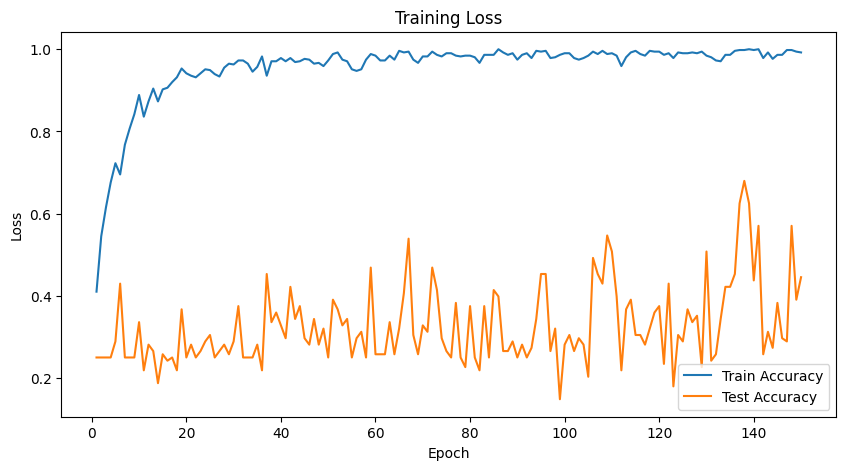

In [214]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(intra_history['epoch'], intra_history['train_accuracy'], label='Train Accuracy')
plt.plot(intra_history['epoch'], intra_history['test_accuracy'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

# Cross subject classification

The model is trained on the cross subject train folder and tested on three unseen subject folders.

In [215]:
cross_model = SimpleCNN(dropout=0.3)

cross_model, cross_history = train_model(
    cross_model,
    cross_train_loader,
    cross_test1_loader,
    epochs=150,
    learning_rate=0.001
)

cross_history

Epoch 1 Train acc: 0.4053 Test acc: 0.2734
Epoch 11 Train acc: 0.8564 Test acc: 0.1289
Epoch 21 Train acc: 0.9404 Test acc: 0.168
Epoch 31 Train acc: 0.9473 Test acc: 0.2695
Epoch 41 Train acc: 0.957 Test acc: 0.2578
Epoch 51 Train acc: 0.9629 Test acc: 0.2617
Epoch 61 Train acc: 0.9854 Test acc: 0.3125
Epoch 71 Train acc: 0.9658 Test acc: 0.25
Epoch 81 Train acc: 0.9756 Test acc: 0.2539
Epoch 91 Train acc: 0.9902 Test acc: 0.1836
Epoch 101 Train acc: 0.9844 Test acc: 0.1992
Epoch 111 Train acc: 0.9805 Test acc: 0.25
Epoch 121 Train acc: 0.9707 Test acc: 0.2461
Epoch 131 Train acc: 0.9961 Test acc: 0.2461
Epoch 141 Train acc: 0.9961 Test acc: 0.5234


,epoch,train_accuracy,test_accuracy
0,1,0.405273,0.273438
1,2,0.586914,0.277344
2,3,0.648438,0.250000
3,4,0.725586,0.234375
4,5,0.740234,0.250000
...,...,...,...
145,146,0.981445,0.250000
146,147,0.984375,0.273438
147,148,0.991211,0.203125
148,149,0.973633,0.261719


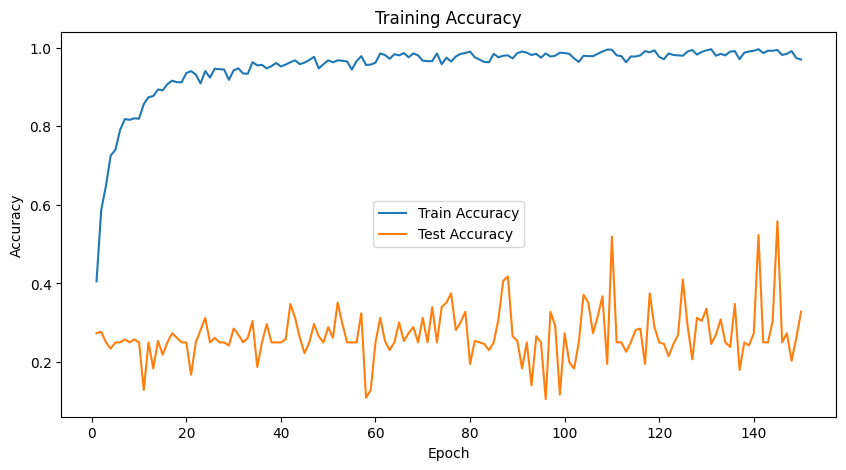

In [221]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(cross_history['epoch'], cross_history['train_accuracy'], label='Train Accuracy')
plt.plot(cross_history['epoch'], cross_history['test_accuracy'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()

In [216]:
cross_test1_acc = evaluate_model(cross_model, cross_test1_loader)
cross_test2_acc = evaluate_model(cross_model, cross_test2_loader)
cross_test3_acc = evaluate_model(cross_model, cross_test3_loader)

results = pd.DataFrame({
    "experiment": ["intra", "cross test1", "cross test2", "cross test3"],
    "accuracy": [
        evaluate_model(intra_model, intra_test_loader),
        cross_test1_acc,
        cross_test2_acc,
        cross_test3_acc
    ]
})

results

,experiment,accuracy
0,intra,0.445312
1,cross test1,0.328125
2,cross test2,0.328125
3,cross test3,0.300781


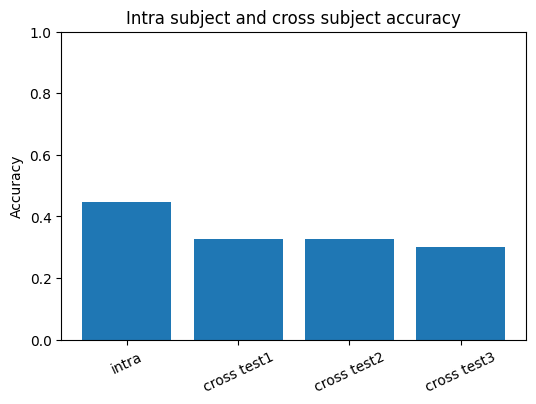

In [217]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(results["experiment"], results["accuracy"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Intra subject and cross subject accuracy")
plt.xticks(rotation=25)
plt.show()

# Hyperparameter test

Here I test a few simple hyperparameter settings. This is useful for discussing how learning rate, batch size and dropout influence the model.

In [218]:
def run_hyperparameter_test(train_X, train_y, test_X, test_y):

    experiments = [
        {"batch_size": 16, "learning_rate": 0.001, "dropout": 0.3},
        {"batch_size": 32, "learning_rate": 0.001, "dropout": 0.3},
        {"batch_size": 16, "learning_rate": 0.0005, "dropout": 0.5}
    ]

    rows = []

    for exp in experiments:
        print("\nExperiment:", exp)

        train_loader = DataLoader(
            MEGDataset(train_X, train_y),
            batch_size=exp["batch_size"],
            shuffle=True
        )

        test_loader = DataLoader(
            MEGDataset(test_X, test_y),
            batch_size=exp["batch_size"],
            shuffle=False
        )

        model = SimpleCNN(dropout=exp["dropout"])

        model, hist = train_model(
            model,
            train_loader,
            test_loader,
            epochs=4,
            learning_rate=exp["learning_rate"]
        )

        final_acc = evaluate_model(model, test_loader)

        rows.append({
            "batch_size": exp["batch_size"],
            "learning_rate": exp["learning_rate"],
            "dropout": exp["dropout"],
            "accuracy": final_acc
        })

    return pd.DataFrame(rows)

In [219]:
hyper_results = run_hyperparameter_test(
    X_intra_train,
    y_intra_train,
    X_intra_test,
    y_intra_test
)

hyper_results


Experiment: {'batch_size': 16, 'learning_rate': 0.001, 'dropout': 0.3}
Epoch 1 Train acc: 0.416 Test acc: 0.25

Experiment: {'batch_size': 32, 'learning_rate': 0.001, 'dropout': 0.3}
Epoch 1 Train acc: 0.375 Test acc: 0.25

Experiment: {'batch_size': 16, 'learning_rate': 0.0005, 'dropout': 0.5}
Epoch 1 Train acc: 0.3477 Test acc: 0.25


,batch_size,learning_rate,dropout,accuracy
0,16,0.0010,0.3,0.265625
1,32,0.0010,0.3,0.250000
2,16,0.0005,0.5,0.312500


# Alternative model

As an extra improvement, I use stronger regularization with dropout and weight decay. This can help when the training accuracy is much higher than the test accuracy.

In [220]:
improved_model = SimpleCNN(dropout=0.5)

improved_model, improved_history = train_model(
    improved_model,
    cross_train_loader,
    cross_test1_loader,
    epochs=8,
    learning_rate=0.0005,
    weight_decay=0.001
)

improved_test1_acc = evaluate_model(improved_model, cross_test1_loader)
improved_test2_acc = evaluate_model(improved_model, cross_test2_loader)
improved_test3_acc = evaluate_model(improved_model, cross_test3_loader)

improved_results = pd.DataFrame({
    "experiment": ["cross test1", "cross test2", "cross test3"],
    "original_accuracy": [cross_test1_acc, cross_test2_acc, cross_test3_acc],
    "improved_accuracy": [improved_test1_acc, improved_test2_acc, improved_test3_acc]
})

improved_results

Epoch 1 Train acc: 0.3672 Test acc: 0.25


,experiment,original_accuracy,improved_accuracy
0,cross test1,0.328125,0.250000
1,cross test2,0.328125,0.289062
2,cross test3,0.300781,0.273438


# Notes for the report

Use these points in your explanation:

1. A 1D CNN is suitable because the MEG files are time series with 248 sensor channels.
2. The model learns temporal patterns after downsampling and normalization.
3. Intra subject classification is expected to perform better, because training and testing come from the same subject.
4. Cross subject classification is harder because brain signals differ between subjects.
5. If training accuracy is much higher than test accuracy, this probably means overfitting.
6. Dropout, weight decay, fewer epochs, more data, or a different model can reduce overfitting.